In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import joblib
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
%matplotlib inline

In [2]:
df = pd.read_csv('../data/processed/features_cwru.csv')
print(f"Dados carregados: {df.shape}")
print(f"\nClasses únicas ({df['classe'].nunique()}):")
print(df['classe'].value_counts().sort_index())

Dados carregados: (2013, 13)

Classes únicas (12):
classe
B007      119
B014      118
B021      119
B028      117
IR007     118
IR014     118
IR021     119
IR028     117
Normal    238
OR007     357
OR014     118
OR021     355
Name: count, dtype: int64


In [3]:
# Features: todas as colunas numéricas extraídas
feature_cols = ['rms', 'kurtosis', 'skewness', 'pico', 'fator_crista',
                'freq_dominante', 'energia_baixa', 'energia_media', 'energia_alta']

X = df[feature_cols].values
y = df['classe'].values

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")
print(f"\nAmostras por classe:")
unique, counts = np.unique(y, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u}: {c}")

Forma de X: (2013, 9)
Forma de y: (2013,)

Amostras por classe:
  B007: 119
  B014: 118
  B021: 119
  B028: 117
  IR007: 118
  IR014: 118
  IR021: 119
  IR028: 117
  Normal: 238
  OR007: 357
  OR014: 118
  OR021: 355


In [4]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Mapeamento das classes:")
for i, classe in enumerate(le.classes_):
    print(f"  {i} -> {classe}")

Mapeamento das classes:
  0 -> B007
  1 -> B014
  2 -> B021
  3 -> B028
  4 -> IR007
  5 -> IR014
  6 -> IR021
  7 -> IR028
  8 -> Normal
  9 -> OR007
  10 -> OR014
  11 -> OR021


In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Média das features após normalização:", X_scaled.mean(axis=0).round(2))
print("Desvio padrão das features após normalização:", X_scaled.std(axis=0).round(2))

Média das features após normalização: [-0.  0.  0.  0.  0. -0. -0.  0. -0.]
Desvio padrão das features após normalização: [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Teste:  {X_test.shape[0]} amostras")

Treino: 1610 amostras
Teste:  403 amostras


In [7]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Dicionário com os modelos
modelos = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=42),
    'SVM': SVC(kernel='rbf', random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}

# Treina cada modelo e guarda a acurácia
resultados = {}
for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    resultados[nome] = acc
    print(f"{nome:15s} -> Acurácia: {acc:.4f}")

# Exibe o melhor modelo
melhor = max(resultados, key=resultados.get)
print(f"\n🏆 Melhor modelo: {melhor} com acurácia de {resultados[melhor]:.4f}")

Random Forest   -> Acurácia: 0.9777
XGBoost         -> Acurácia: 0.9826
SVM             -> Acurácia: 0.9082
KNN             -> Acurácia: 0.9429

🏆 Melhor modelo: XGBoost com acurácia de 0.9826


📋 RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

        B007       1.00      1.00      1.00        24
        B014       0.88      0.92      0.90        24
        B021       0.95      0.83      0.89        24
        B028       1.00      1.00      1.00        23
       IR007       1.00      1.00      1.00        23
       IR014       1.00      0.96      0.98        24
       IR021       1.00      1.00      1.00        24
       IR028       1.00      1.00      1.00        23
      Normal       1.00      1.00      1.00        48
       OR007       0.96      1.00      0.98        71
       OR014       1.00      1.00      1.00        24
       OR021       1.00      1.00      1.00        71

    accuracy                           0.98       403
   macro avg       0.98      0.98      0.98       403
weighted avg       0.98      0.98      0.98       403

🎯 MATRIZ DE CONFUSÃO
[[24  0  0  0  0  0  0  0  0  0  0  0]
 [ 0 22  1  0  0  0  0  0  0  1  0  0]
 [ 0 

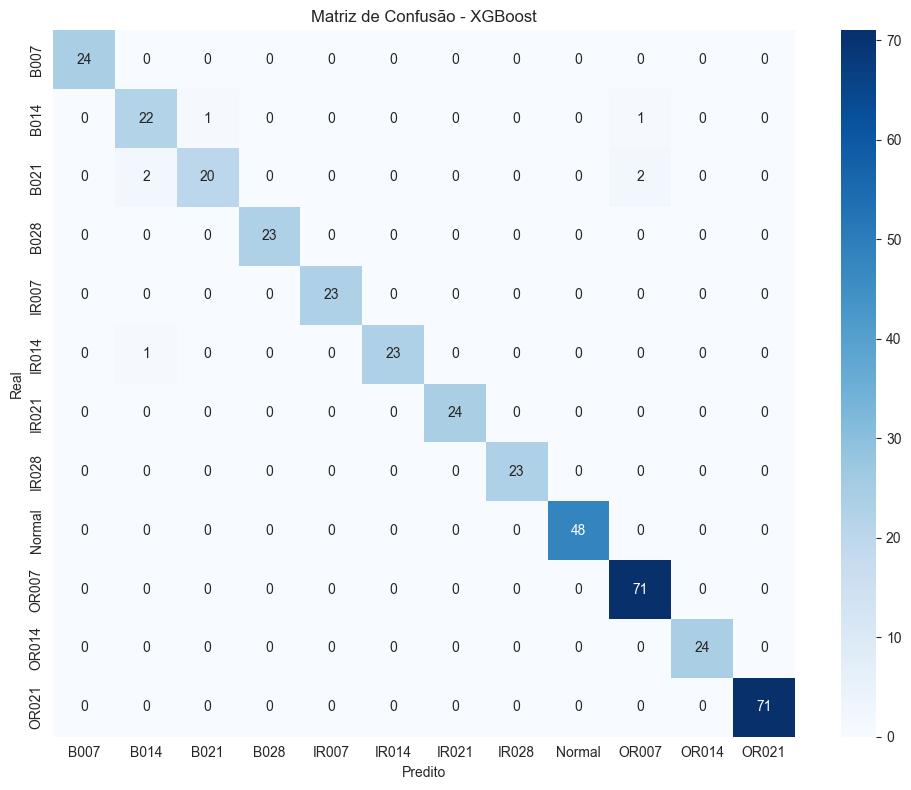

In [8]:
from sklearn.metrics import classification_report, confusion_matrix

# Pega o melhor modelo (XGBoost)
melhor_modelo = modelos[melhor]
y_pred = melhor_modelo.predict(X_test)

# Relatório de classificação
print("=" * 50)
print("📋 RELATÓRIO DE CLASSIFICAÇÃO")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Matriz de confusão
print("=" * 50)
print("🎯 MATRIZ DE CONFUSÃO")
print("=" * 50)
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Plot visual da matriz de confusão
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'Matriz de Confusão - {melhor}')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

In [9]:
import joblib

# Salva o melhor modelo
joblib.dump(modelos[melhor], '../models/xgboost_cwru.pkl')
print("Modelo XGBoost salvo como models/xgboost_cwru.pkl")

# Salva o scaler (necessário para normalizar novos dados)
joblib.dump(scaler, '../models/scaler.pkl')
print("Scaler salvo como models/scaler.pkl")

# Salva o LabelEncoder (para traduzir números de volta para nomes das classes)
joblib.dump(le, '../models/label_encoder.pkl')
print("LabelEncoder salvo como models/label_encoder.pkl")

Modelo XGBoost salvo como models/xgboost_cwru.pkl
Scaler salvo como models/scaler.pkl
LabelEncoder salvo como models/label_encoder.pkl


In [15]:
import numpy as np
from scipy import stats

def extrair_caracteristicas(sinal, fs=12000):
    n = len(sinal)
    
    # --- Domínio do tempo ---
    rms = np.sqrt(np.mean(sinal**2))
    kurtosis = stats.kurtosis(sinal)
    skewness = stats.skew(sinal)
    pico = np.max(np.abs(sinal))
    fator_crista = pico / (rms + 1e-10)
    
    # --- Domínio da frequência ---
    magnitude = np.abs(np.fft.rfft(sinal))
    frequencias = np.fft.rfftfreq(n, d=1/fs)
    
    min_len = min(len(magnitude), len(frequencias))
    magnitude = magnitude[:min_len]
    frequencias = frequencias[:min_len]
    
    idx_pico = np.argmax(magnitude)
    freq_dominante = frequencias[idx_pico]
    
    energia_baixa = np.sum(magnitude[(frequencias >= 0) & (frequencias < 1000)])
    energia_media = np.sum(magnitude[(frequencias >= 1000) & (frequencias < 3000)])
    energia_alta = np.sum(magnitude[(frequencias >= 3000) & (frequencias < 6000)])
    
    return {
        'rms': rms,
        'kurtosis': kurtosis,
        'skewness': skewness,
        'pico': pico,
        'fator_crista': fator_crista,
        'freq_dominante': freq_dominante,
        'energia_baixa': energia_baixa,
        'energia_media': energia_media,
        'energia_alta': energia_alta
    }

In [16]:
from pathlib import Path
pasta_1797 = Path('../data/1797 RPM')

In [17]:
# Carrega um sinal de exemplo (IR007)
dados_teste = np.load(pasta_1797 / '1797_IR_7_DE12.npz')
sinal_teste = dados_teste['DE'].flatten()

# Pega uma janela do meio (como se fosse um "novo dado")
janela_teste = sinal_teste[5000:5000+1024]

# Extrai características
feat_teste = extrair_caracteristicas(janela_teste)
X_teste = np.array([list(feat_teste.values())]).reshape(1, -1)

# Normaliza
X_teste_scaled = scaler.transform(X_teste)

# Prediz
pred_id = modelos[melhor].predict(X_teste_scaled)[0]
pred_classe = le.inverse_transform([pred_id])[0]
proba = modelos[melhor].predict_proba(X_teste_scaled)[0][pred_id]

print(f"Janela de teste extraída do arquivo IR007")
print(f"Classe predita: {pred_classe}")
print(f"Confiança: {proba:.2%}")

Janela de teste extraída do arquivo IR007
Classe predita: IR007
Confiança: 99.75%
